# Lab 6. Matrices
Hardware 1 - Mathematics Python Labs<br>
Information and Communication Technology<br>
Metropolia University of Applied Sciences

## Setup

Remember add your `name`, `student_id`, and `date_returned`.

Read necessary libraries and functions.

In [46]:
name = "Daniel Larva"
student_id = 2511908 # Write your student number here
date_returned = "14/2/2026"

In [47]:
import numpy as np
import matplotlib.pyplot as plt

---
## Problem 1

In this problem the aim is to practise matrix multiplication (dot product). The matrices A and B generated by the code. Your task is:

1. Calculate the matrix dot product $C = AB$ and print it out. 
2. Calculate the matrix dot product  $D = BA$ and print it out.
3. Compare C and D. What do you observe?

Tips
- Study `numpy.isclose()` and `numpy.allclose()` and use them for comparison
- Use `numpy.round()` to round the results of dot product to few decimals. 


In [48]:
# Initialize random number generator
rng = np.random.default_rng(student_id)

# Generate two random matrices
A = rng.integers(low=0, high=10, size=(5, 5))
B = np.linalg.inv(A)

# Print them
print('A = \n', A)
print('B = \n', B)

A = 
 [[8 7 7 8 3]
 [1 6 7 2 6]
 [1 6 3 1 4]
 [5 9 6 5 9]
 [0 8 7 5 7]]
B = 
 [[ 5.40641312e-02  7.75540641e-02 -3.72856078e-04  9.80611484e-02
  -2.15510813e-01]
 [ 4.32513050e-02 -1.37956749e-01  3.99701715e-01 -1.21551081e-01
   2.75913497e-02]
 [ 5.63012677e-02  2.94556301e-01 -8.31469053e-02 -1.32363908e-01
  -5.89112603e-02]
 [ 3.20656227e-02 -2.22967934e-01 -1.86428039e-01  3.05741984e-02
   2.44593587e-01]
 [-1.28635347e-01  2.23713647e-02 -2.40492170e-01  2.49440716e-01
  -4.47427293e-03]]


In [49]:
# My code to solve C = AB
C = np.dot(A, B)
Cround = np.round(C, 3)
print('C = AB = \n', Cround)

C = AB = 
 [[ 1.  0.  0.  0. -0.]
 [-0.  1.  0.  0. -0.]
 [-0.  0.  1.  0.  0.]
 [-0.  0. -0.  1. -0.]
 [ 0. -0.  0.  0.  1.]]


In [50]:
# My code to solve D = BA
D = np.dot(B, A)
Dround = np.round(D, 3)
print('D = BA = \n', Dround)


D = BA = 
 [[ 1.  0.  0. -0.  0.]
 [-0.  1. -0. -0. -0.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  0. -0.  1. -0.]
 [ 0.  0.  0.  0.  1.]]


In [51]:
# Compare C and D 
allc = np.allclose(C, D)
print(f'Are the matrices equal element-wise? {allc}')
isc = np.isclose(C, D)
print(f'Matrices C and D are about equal in the following positions:\n {isc}')

Are the matrices equal element-wise? True
Matrices C and D are about equal in the following positions:
 [[ True  True  True  True  True]
 [ True  True  True  True  True]
 [ True  True  True  True  True]
 [ True  True  True  True  True]
 [ True  True  True  True  True]]


---
## Problem 2

in this problem the aim is first to use numpy's function to solve equations and then write own algorithm to do the same thing. Again, the arrays A and b are generated for you. You need not to write them yourself.

First, use `numpy.linalg.solve()` to solve these equations:

\begin{align*} 
A_{11} x + A_{12} y + A_{13} z &=  b_1 \\ 
A_{21} x + A_{22} y + A_{23} z &= b_2 \\
A_{31} x + A_{32} y + A_{33} z &= b_3
\end{align*}

Then, write your own code to solve them. In your own code:
- Do NOT use numpy function NOR any other ready-made functions, but
- Write your own algorithm to solve the equations

Finally, compare the solutions and verify they give same results. Use `numpy.isclose()` function for that. 

In [52]:
# Initialize random number generator
rng = np.random.default_rng(student_id)

# Generate two random matrices
A = rng.integers(low=-10, high=10, size=(3, 3))
b = rng.integers(low=-10, high=10, size=(3, 1))

# Print them
print('A = \n', A)
print('b = \n', b)

A = 
 [[ 6  5  4]
 [ 6 -4 -8]
 [ 2  5 -6]]
b = 
 [[ 2]
 [-8]
 [ 2]]


In [53]:
# Using numpy.linalg.solve to solve Ax = b
sol = np.linalg.solve(A, b)
solRnd = np.round(sol, 2)
print('solutions =', solRnd)

solutions = [[-0.5 ]
 [ 0.84]
 [ 0.2 ]]


In [54]:
# My code to solve the linear equations for x, y and z
newA = np.concatenate((A, b), axis=1)

n = 0

for i in newA[1]:
    i = i - newA[0, n]
    newA[1, n] = i
    n += 1

divide = newA[0, 0] / newA[2, 0]
n = 0

for i in newA[2]:
    i = i * divide
    newA[2, n] = i
    n += 1

n = 0
for i in newA[2]:
    i = i - newA[0, n]
    newA[2, n] = i
    n += 1

divide = -1 * (newA[2, 1] / newA[1, 1])
n = 0
for i in newA[1]:
    i = i * divide
    newA[1, n] = i
    n += 1

n = 0
for i in newA[2]:
    i = i + newA[1, n]
    newA[2, n] = i
    n += 1

z = newA[2, 3] / newA[2, 2]

r1c2 = newA[1, 2] * z
r1c3 = newA[1, 3] - r1c2
y = r1c3 / newA[1, 1]

r0c1 = newA[0, 1] * y
r0c2 = newA[0, 2] * z
r0c3 = newA[0, 3] - r0c2 - r0c1
x = r0c3 / newA[0, 0]

mySol = np.array([[x], [y], [z]])


print(newA)
print(f"my solutions =\n {mySol}")
print(f"numpy's solutions =\n {solRnd}")

[[  6   5   4   2]
 [  0 -10 -13 -11]
 [  0   0 -35  -7]]
my solutions =
 [[-0.5 ]
 [ 0.84]
 [ 0.2 ]]
numpy's solutions =
 [[-0.5 ]
 [ 0.84]
 [ 0.2 ]]


In [55]:
# Compare the results and verify they give same results
compare = np.isclose(solRnd, mySol)
print(f'The solutions are about equal in the following positions:\n {compare}')

The solutions are about equal in the following positions:
 [[ True]
 [ True]
 [ True]]


---
## Problem 3
Solve the following equations using numpy linear algebra operations

$$ Ax = b $$

Notice, that A and b are already defined, you don't need to rewrite them.

Give the values for x with three decimals.

In [56]:
# Initialize random number generator
rng = np.random.default_rng(student_id)

# Generate two random matrices
A = np.round(rng.uniform(-1000, 1000, size=(7, 7)), 4)
b = A @ np.arange(1, 8).reshape((7, 1))

# Print them
print('A = \n', A)
print('b = \n', b)

A = 
 [[ 562.411   646.1174 -762.9356  557.4824  266.7975  261.0382 -664.9743]
 [ 176.9459  247.6863  933.5873  742.2966  152.3078  812.2386   67.5646]
 [ 307.6482  650.7929  140.9363 -566.0341  246.4022 -693.0793 -445.084 ]
 [-803.4632 -862.3311 -693.7868  119.8004 -653.0624 -576.7569  711.924 ]
 [-478.7514  262.6484  558.6774  861.705   628.0826  223.7481  -11.9888]
 [-558.8173  -68.6542 -264.768   126.3287 -951.9923  686.1199  244.6001]
 [ 785.0618 -571.9429  225.5638 -403.6251 -520.9776   11.2869   48.8267]]
b = 
 [[   41.1652]
 [12550.1896]
 [-6274.1463]
 [-5872.6696]
 [ 9568.3776]
 [   83.8437]
 [-3492.0127]]


In [57]:
# My solution for problem 3
x = np.linalg.solve(A, b)
xRnd = np.round(x, 3)
test = np.allclose(np.dot(A, x), b) #Test that the values for x work
print(test)
print(xRnd)

True
[[1.]
 [2.]
 [3.]
 [4.]
 [5.]
 [6.]
 [7.]]


---
## Problem 4

Consider a $9 \times 9$ matrix $A$, where each element is defined by the following formula

$A_{nm} = (-1)^{(n+m)} \cdot (n + 2m)$

where both indices n and m range from 1 to 9 (inclusive).

Your task is:

- Step 1. Matrix construction 
   - Write a Python program using numpy to construct this matrix. Do not manually type each element!
- Step 2. Determinant calculation
   - Calculate the determinant of matrix A using numpy's build-in functions.
- Step 3. Analysis
   - What is the determinant value?
   - What does that tell you about the matrix?

Tips
- Here you **can use for-loops** for indexing both rows and columns of the array
- Notice, that indexing in numpy arrays starts from 0, but for the formula it starts from 1. You should take care of this in your code.
- It is a good practise first to initialize the array. You can do that for example using the function `numpy.zeros()`.

In [58]:
# My solution for problem 4
A = np.zeros((9, 9))
i = 0

for n in A:
    j = 0
    for m in n:
        n[j] = (((-1)**((i+1)+(j+1)))*((i+1)+(2*(j+1))))
        if j < 8:
            j += 1
    if i < 8:
        i += 1

detA = np.linalg.det(A)

print(f"Matrix A:\n {A}")
print(f"Determinant of A:\n {detA}")
print(f"The determinant being {detA} means that the inverse of A does not exist.")

Matrix A:
 [[  3.  -5.   7.  -9.  11. -13.  15. -17.  19.]
 [ -4.   6.  -8.  10. -12.  14. -16.  18. -20.]
 [  5.  -7.   9. -11.  13. -15.  17. -19.  21.]
 [ -6.   8. -10.  12. -14.  16. -18.  20. -22.]
 [  7.  -9.  11. -13.  15. -17.  19. -21.  23.]
 [ -8.  10. -12.  14. -16.  18. -20.  22. -24.]
 [  9. -11.  13. -15.  17. -19.  21. -23.  25.]
 [-10.  12. -14.  16. -18.  20. -22.  24. -26.]
 [ 11. -13.  15. -17.  19. -21.  23. -25.  27.]]
Determinant of A:
 0.0
The determinant being 0.0 means that the inverse of A does not exist.


---
## Problem 5


If $ A(a, x) = \left( \begin{matrix}
a + x & a - x & a - x \\
a - x & a + x & a - x \\
a - x & a - x & a + x
\end{matrix} \right)$, find $x > 0$, so that $det(A(a, x)) = 0$. 

How are $a$ and $x$ related?

This last problem can be solved combining matrix operations and graphics.

Tips
- First, create a function that returns a numerical matrix for input variables a and x
- Create a second function that calls the first function and calculates and returns the determinant value of the matrix. 
- Create linearly spaced values for $x \in [0, 10]$, for example. Use `numpy.linspace`.
- Calculate the output of the second function (e.g. $f(x,a) = det(A(x, a))$) and store the values to another variable, for example y. 
- Draw a graph of the determinant versus value of x, e.g. plot(x, y) 
- Finally, from the graph, find the value of x, when $y = 0$.
- **NOTE** $x = 0$ is NOT the answer we are looking for! 

The value for $a$ is given below for you.

In [59]:
# Initialize random number generator
rng = np.random.default_rng(student_id)

# Generate random value for a
a = np.round(rng.uniform(1.0, 3.0), 1)
print(f'a = {a}')

a = 2.6


If the determinant is 0, then x = 7.8


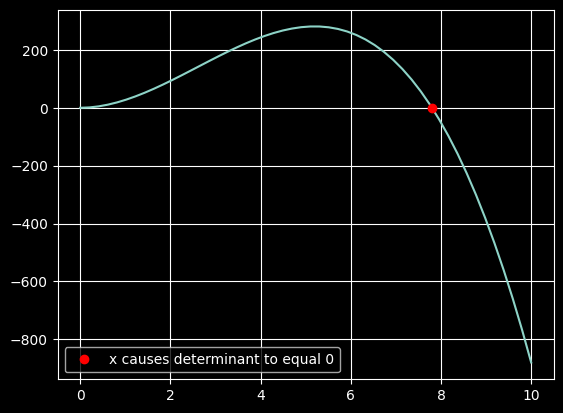

In [78]:
# Solution for problem 5

def funky_matrix(a, x):
    a = float(a)
    #x = float(x)
    ad = a + x
    sub = a - x
    matrix = np.array([[ad, sub, sub], [sub, ad, sub], [sub, sub, ad]])
    return matrix

def det_funk(a, x):
    dets = []
    for i in x:
        matrix = funky_matrix(a, i)
        det = np.linalg.det(matrix)
        dets.append(det)
    return np.array(dets)

x = np.linspace(0,10)
y = det_funk(a, x)
plt.plot(x, y)
#plt.ylim(-10, 10)
plt.grid()
plt.plot(7.8, 0, 'ro', label = 'x causes determinant to equal 0')
plt.legend()
print(f'If the determinant is 0, then x = 7.8')

In [77]:
#I will test to see if it checks out
check = funky_matrix(a, 7.8)
detcheck = np.linalg.det(check)
print(np.round(detcheck, 3))
print("Checks out! Even np.isclose says:")
print(np.isclose(detcheck, 0))

0.0
Checks out! Even np.isclose says:
True
